In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.fetch_nasa_omni_historical import load_and_clean_nasa_omni_historical
from src.features.transformers import SolarWindTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Ensure results directory exists
os.makedirs('../results', exist_ok=True)

In [3]:
omni_2023 = load_and_clean_nasa_omni_historical(2023, "../data/raw/")
omni_2023 = SolarWindTransformer.transform(omni_2023, speed_col='Plasma_Speed', bz_col='Bz_GSE', time_col='time_tag')

print(f"Total features after engineering: {len(omni_2023.columns)}")
print(f"Features: {list(omni_2023.columns)}")
print(f"Target: Kp_index")


2026-03-04 14:56:47,619 - INFO - Found existing raw data file for year 2023 at ../data/raw/omni2_2023_raw.csv. Loading...


Total features after engineering: 18
Features: ['Year', 'DOY', 'Hour', 'IMF_Mag', 'Bx_GSE', 'By_GSE', 'Bz_GSE', 'Proton_Density', 'Plasma_Speed', 'Kp_index', 'Kp_real', 'lag_min', 'Bz_South', 'Energy_Flux', 'Energy_3h_Avg', 'Speed_6h_Max', 'B_total', 'B_azimuth']
Target: Kp_index


In [4]:
feature_selection_log = []

In [5]:
numeric_cols = omni_2023.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {len(numeric_cols)}")
print(f"Removed: {set(omni_2023.columns) - set(numeric_cols)}")

for col in numeric_cols:
    feature_selection_log.append({
        'Feature': col,
        'Step': 'Initial',
        'Status': 'Keep',
        'Reason': 'Numeric'
    })

omni_numeric = omni_2023[numeric_cols]

Numeric features: 18
Removed: set()


In [6]:
target = 'Kp_index'
if target in omni_numeric.columns:
    features = [col for col in omni_numeric.columns if col != target]
    print(f"Target: {target}")
    print(f"Features remaining: {len(features)}")
else:
    print(f"WARNING: Target '{target}' not found!")
    features = omni_numeric.columns.tolist()

Target: Kp_index
Features remaining: 17


In [7]:
variance_threshold = 0.01
variances = omni_numeric[features].var()
low_var_features = variances[variances < variance_threshold].index.tolist()

print(f"Threshold: {variance_threshold}")
print(f"Low variance features ({len(low_var_features)}):")
for feat in low_var_features:
    print(f"  - {feat}: variance = {variances[feat]:.6f}")
    feature_selection_log.append({
        'Feature': feat,
        'Step': 'Variance Threshold',
        'Status': 'Remove',
        'Reason': f'Low variance: {variances[feat]:.6f}'
    })

features_after_var = [f for f in features if f not in low_var_features]
print(f"Features remaining: {len(features_after_var)}")

Threshold: 0.01
Low variance features (1):
  - Year: variance = 0.000000
Features remaining: 16


In [8]:
missing_pct = (omni_numeric[features_after_var + [target]].isna().sum() / len(omni_numeric)) * 100
missing_threshold = 50

high_missing = missing_pct[missing_pct > missing_threshold].index.tolist()
if target in high_missing:
    high_missing.remove(target)

print(f"Missing data threshold: {missing_threshold}%")
print(f"High missing features ({len(high_missing)}):")
for feat in high_missing:
    print(f"  - {feat}: {missing_pct[feat]:.1f}% missing")
    feature_selection_log.append({
        'Feature': feat,
        'Step': 'Missing Data',
        'Status': 'Remove',
        'Reason': f'{missing_pct[feat]:.1f}% missing'
    })

features_after_missing = [f for f in features_after_var if f not in high_missing]
print(f"Features remaining: {len(features_after_missing)}")

Missing data threshold: 50%
High missing features (0):
Features remaining: 16


In [9]:
corr_threshold = 0.95
corr_matrix = omni_numeric[features_after_missing].corr().abs()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > corr_threshold:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"High correlation pairs (r > {corr_threshold}):")
    for pair in high_corr_pairs:
        print(f"  - {pair['Feature1']} ↔ {pair['Feature2']}: r = {pair['Correlation']:.3f}")


High correlation pairs (r > 0.95):
  - Bx_GSE ↔ Bz_GSE: r = 0.964
  - Plasma_Speed ↔ lag_min: r = 0.972
  - Plasma_Speed ↔ Speed_6h_Max: r = 0.984
  - lag_min ↔ Speed_6h_Max: r = 0.959
  - Bz_South ↔ Energy_Flux: r = 0.974


In [16]:
# Remove one from each pair (keep the one with higher target correlation)
features_to_remove_corr = set()
target_corr = omni_numeric[features_after_missing + [target]].corr()[target].drop(target)

for pair in high_corr_pairs:
    f1, f2 = pair['Feature1'], pair['Feature2']
    if abs(target_corr[f1]) >= abs(target_corr[f2]):
        features_to_remove_corr.add(f2)
    else:
        features_to_remove_corr.add(f1)

for feat in features_to_remove_corr:
    feature_selection_log.append({
        'Feature': feat,
        'Step': 'Multicollinearity',
        'Status': 'Remove',
        'Reason': f'Highly correlated with another feature'
    })

features_after_corr = [f for f in features_after_missing if f not in features_to_remove_corr]
print(f"Features removed: {len(features_to_remove_corr)}" + ": " + ", ".join(features_to_remove_corr))
print(f"Features remaining: {len(features_after_corr)}")

Features removed: 4: Bz_GSE, Speed_6h_Max, Bz_South, lag_min
Features remaining: 12


Correlation with Kp_index:
Kp_real           1.000000
Plasma_Speed      0.476156
B_total           0.369575
By_GSE            0.341974
Energy_3h_Avg     0.259155
Energy_Flux       0.249583
Proton_Density    0.247513
B_azimuth         0.205915
DOY               0.077782
Bx_GSE            0.062558
Hour              0.017018
IMF_Mag           0.002553
Name: Kp_index, dtype: float64


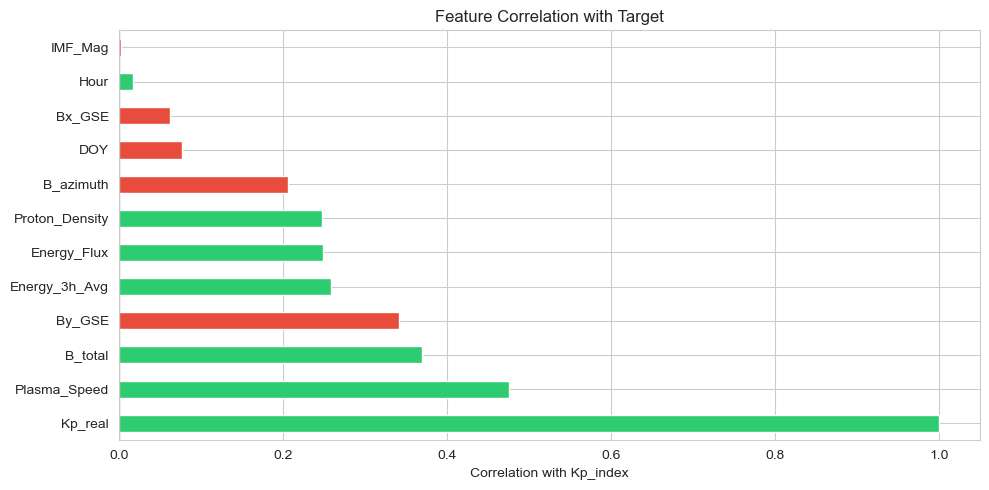

In [12]:
target_corr = omni_numeric[features_after_corr + [target]].corr()[target].drop(target)
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Correlation with Kp_index:")
print(target_corr_sorted)

# Visualize correlations
fig, ax = plt.subplots(figsize=(10, max(5, len(features_after_corr) * 0.4)))
colors = ['#2ecc71' if target_corr[f] > 0 else '#e74c3c' for f in target_corr_sorted.index]
target_corr_sorted.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Kp_index')
ax.set_title('Feature Correlation with Target')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

Mutual Information with Kp_index:
Kp_real           2.655271
DOY               0.696760
Plasma_Speed      0.165667
By_GSE            0.137968
B_total           0.098298
Energy_3h_Avg     0.074777
Proton_Density    0.070748
B_azimuth         0.065713
Bx_GSE            0.053351
Energy_Flux       0.052775
IMF_Mag           0.029234
Hour              0.006952
dtype: float64


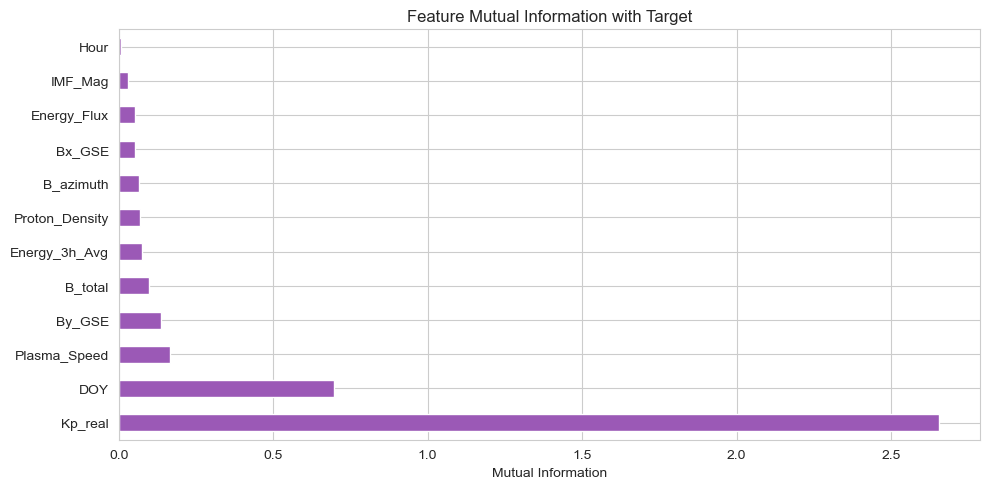

In [13]:
X_clean = omni_numeric[features_after_corr].dropna()
y_clean = omni_numeric.loc[X_clean.index, target]

X_scaled = StandardScaler().fit_transform(X_clean)
mi_scores = mutual_info_regression(X_scaled, y_clean, random_state=42)
mi_sorted = pd.Series(mi_scores, index=features_after_corr).sort_values(ascending=False)

print("Mutual Information with Kp_index:")
print(mi_sorted)

# Visualize MI scores
fig, ax = plt.subplots(figsize=(10, max(5, len(features_after_corr) * 0.4)))
mi_sorted.plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_xlabel('Mutual Information')
ax.set_title('Feature Mutual Information with Target')
plt.tight_layout()
plt.show()

In [14]:
safe_features = ['Plasma_Speed', 'Proton_Density', 'Bx_GSE', 'By_GSE', 'Bz_GSE']
derived_features = [f for f in features_after_corr if f not in safe_features]

print(f"Safe features (direct measurements): {safe_features}")
print(f"Derived features: {derived_features}")

# Flag features that might be leakage
leakage_risk = []
for feat in derived_features:
    if 'Energy' in feat or 'lag' in feat or 'Impact' in feat:
        # These are derived but not from Kp - they're safe
        feature_selection_log.append({
            'Feature': feat,
            'Step': 'Leakage Check',
            'Status': 'Keep',
            'Reason': 'Derived feature (safe - physical relationship)'
        })
    else:
        feature_selection_log.append({
            'Feature': feat,
            'Step': 'Leakage Check',
            'Status': 'Keep',
            'Reason': 'No direct leakage detected'
        })

print(f"No leakage detected in remaining features")

Safe features (direct measurements): ['Plasma_Speed', 'Proton_Density', 'Bx_GSE', 'By_GSE', 'Bz_GSE']
Derived features: ['DOY', 'Hour', 'IMF_Mag', 'Kp_real', 'Energy_Flux', 'Energy_3h_Avg', 'B_total', 'B_azimuth']
No leakage detected in remaining features


In [15]:
final_features = features_after_corr
print(f"\nSelected {len(final_features)} features:")
for i, feat in enumerate(final_features, 1):
    corr = target_corr[feat]
    mi = mi_sorted[feat] if feat in mi_sorted else np.nan
    print(f"  {i}. {feat:20s} | r={corr:+.3f} | MI={mi:.4f}" if not np.isnan(mi) else f"  {i}. {feat:20s} | r={corr:+.3f}")

# Cell 13: Create Feature Selection Report
print("\n=== FEATURE SELECTION REPORT ===\n")

# Summary statistics
summary_data = {
    'Stage': [
        'Initial Features',
        'After Variance Threshold',
        'After Missing Data',
        'After Multicollinearity',
        'Final Selection'
    ],
    'Count': [
        len(features),
        len(features_after_var),
        len(features_after_missing),
        len(features_after_corr),
        len(final_features)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save feature selection log
feature_log_df = pd.DataFrame(feature_selection_log)
feature_log_df_dropped = feature_log_df[feature_log_df['Status'] == 'Remove'].drop_duplicates(subset=['Feature']).reset_index(drop=True)
feature_log_df_kept = feature_log_df[feature_log_df['Status'] == 'Keep'].drop_duplicates(subset=['Feature']).reset_index(drop=True)

print("\n--- Dropped Features ---")
print(feature_log_df_dropped.to_string(index=False))

print("\n--- Kept Features ---")
print(feature_log_df_kept.to_string(index=False))


Selected 12 features:
  1. DOY                  | r=-0.078 | MI=0.6968
  2. Hour                 | r=+0.017 | MI=0.0070
  3. IMF_Mag              | r=-0.003 | MI=0.0292
  4. Bx_GSE               | r=-0.063 | MI=0.0534
  5. By_GSE               | r=-0.342 | MI=0.1380
  6. Proton_Density       | r=+0.248 | MI=0.0707
  7. Plasma_Speed         | r=+0.476 | MI=0.1657
  8. Kp_real              | r=+1.000 | MI=2.6553
  9. Energy_Flux          | r=+0.250 | MI=0.0528
  10. Energy_3h_Avg        | r=+0.259 | MI=0.0748
  11. B_total              | r=+0.370 | MI=0.0983
  12. B_azimuth            | r=-0.206 | MI=0.0657

=== FEATURE SELECTION REPORT ===

                   Stage  Count
        Initial Features     17
After Variance Threshold     16
      After Missing Data     16
 After Multicollinearity     12
         Final Selection     12

--- Dropped Features ---
     Feature               Step Status                                 Reason
        Year Variance Threshold Remove                 

In [ ]:
# Cell 1: Setup & Imports


# Cell 2: Load Data & Engineer Features

# Cell 3: Initialize Feature Selection Report


print("\n=== FEATURE SELECTION PIPELINE ===\n")

# Cell 4: Step 1 - Remove Non-Numeric Features
print("STEP 1: Remove Non-Numeric Features")


# Cell 5: Step 2 - Target Variable Handling
print("\nSTEP 2: Identify Target Variable")


# Cell 6: Step 3 - Variance Threshold
print("\nSTEP 3: Variance Threshold (Remove Low-Variance Features)")


# Cell 7: Step 4 - Missing Data Check
print("\nSTEP 4: Missing Data Analysis")


# Cell 8: Step 5 - Multicollinearity Check (VIF approximation)
print("\nSTEP 5: Multicollinearity Check (Correlation-based)")



# Cell 9: Step 6 - Target Correlation Analysis
print("\nSTEP 6: Target Correlation Analysis")


# Cell 10: Step 7 - Mutual Information (Non-linear relationships)
print("\nSTEP 7: Mutual Information Analysis")


# Cell 11: Step 8 - Leakage Check
print("\nSTEP 8: Leakage Check")
print("Checking for data leakage (features derived directly from target):")

# Define known safe features (physical measurements, not derived from Kp)


# Cell 12: Final Feature Set
print("\nSTEP 9: FINAL FEATURE SET")


# Cell 14: Save Results
# Save feature selection log
feature_log_df_dropped.to_csv('../results/feature_selection_dropped.csv', index=False)
feature_log_df_kept.to_csv('../results/feature_selection_kept.csv', index=False)
summary_df.to_csv('../results/feature_selection_summary.csv', index=False)

# Save final feature list
final_features_df = pd.DataFrame({
    'Feature': final_features,
    'Correlation_with_Kp': [target_corr[f] for f in final_features],
    'Mutual_Information': [mi_sorted[f] if f in mi_sorted else np.nan for f in final_features],
    'Rank_by_MI': range(1, len(final_features) + 1)
})
final_features_df = final_features_df.sort_values('Mutual_Information', ascending=False).reset_index(drop=True)
final_features_df.to_csv('../results/final_feature_set.csv', index=False)

print(f"\n✓ Results saved to ../results/")
print(f"  - feature_selection_dropped.csv")
print(f"  - feature_selection_kept.csv")
print(f"  - feature_selection_summary.csv")
print(f"  - final_feature_set.csv")

# Cell 15: Visualization Summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Feature count by stage
axes[0, 0].bar(summary_df['Stage'].str.replace(' ', '\n'), summary_df['Count'], color='#3498db')
axes[0, 0].set_ylabel('Number of Features')
axes[0, 0].set_title('Feature Elimination Pipeline')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Reasons for removal
removal_reasons = feature_log_df_dropped['Reason'].value_counts()
axes[0, 1].barh(removal_reasons.index, removal_reasons.values, color='#e74c3c')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Reasons for Feature Removal')

# Plot 3: Final features ranked by MI
final_features_sorted = final_features_df.sort_values('Mutual_Information')
axes[1, 0].barh(final_features_sorted['Feature'], final_features_sorted['Mutual_Information'], color='#2ecc71')
axes[1, 0].set_xlabel('Mutual Information')
axes[1, 0].set_title('Final Features (Ranked by MI)')

# Plot 4: Correlation vs MI
final_features_df_sorted = final_features_df.sort_values('Feature')
axes[1, 1].scatter(abs(final_features_df_sorted['Correlation_with_Kp']), 
                   final_features_df_sorted['Mutual_Information'], s=100, color='#9b59b6', alpha=0.7)
for idx, row in final_features_df_sorted.iterrows():
    axes[1, 1].annotate(row['Feature'], 
                        (abs(row['Correlation_with_Kp']), row['Mutual_Information']),
                        fontsize=8, alpha=0.7)
axes[1, 1].set_xlabel('|Correlation with Kp_index|')
axes[1, 1].set_ylabel('Mutual Information')
axes[1, 1].set_title('Correlation vs Mutual Information')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== FEATURE SELECTION COMPLETE ===")